https://www.kaggle.com/datasets/samxsam/human-cognitive-performance-analysis/data

The metohd used in this script is inspired by the metohd used in: Poretto, V., Endrizzi, W., Betti, M., Bovo, S., Bellinvia, A., Ragni, F., ... & Amato, M. P. (2025). Machine Learning Analysis Applied to Prediction of Early Progression Independent of Relapse Activity in Multiple Sclerosis Patients. European Journal of Neurology, 32(12), e70417.

**Research Question**

What is the predictive performance of standard regression models (Ridge and RandomForest) for predicting individual cognitive performance based on demographic and behavioral variables?



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.inspection import permutation_importance

In [ ]:
path = "/content/drive/MyDrive/Test_ML/CognitivePerformance/human_cognitive_performance.csv"
df = pd.read_csv(path)

In [ ]:
df.head()

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
0,U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77
1,U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68
2,U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54
3,U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59
4,U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             80000 non-null  object 
 1   Age                 80000 non-null  int64  
 2   Gender              80000 non-null  object 
 3   Sleep_Duration      80000 non-null  float64
 4   Stress_Level        80000 non-null  int64  
 5   Diet_Type           80000 non-null  object 
 6   Daily_Screen_Time   80000 non-null  float64
 7   Exercise_Frequency  80000 non-null  object 
 8   Caffeine_Intake     80000 non-null  int64  
 9   Reaction_Time       80000 non-null  float64
 10  Memory_Test_Score   80000 non-null  int64  
 11  Cognitive_Score     80000 non-null  float64
 12  AI_Predicted_Score  80000 non-null  float64
dtypes: float64(5), int64(4), object(4)
memory usage: 7.9+ MB


The dataset consists of 80000 rows and 13 columns. There do not appear to be any missing values in any of the columns. The data type within each column seems to be consistent (e.g., there are no numeric data encoded as strings).

# Exploratory Data Analysis

In [ ]:
df.describe(include = "all")

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
count,80000,80000.000000,80000,80000.000000,80000.000000,80000,80000.000000,80000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
unique,80000,NaN,3,NaN,NaN,3,NaN,3,NaN,NaN,NaN,NaN,NaN
top,U79984,NaN,Female,NaN,NaN,Non-Vegetarian,NaN,Medium,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,38404,NaN,NaN,47986,NaN,31990,NaN,NaN,NaN,NaN,NaN
mean,NaN,38.525525,NaN,7.005332,5.493762,NaN,6.504646,NaN,248.988213,399.973579,69.498350,58.172395,58.121357
std,NaN,12.101876,NaN,1.734435,2.865308,NaN,3.167072,NaN,144.541990,115.369329,17.305659,23.058522,23.119598
min,NaN,18.000000,NaN,4.000000,1.000000,NaN,1.000000,NaN,0.000000,200.000000,40.000000,0.000000,0.000000
25%,NaN,28.000000,NaN,5.500000,3.000000,NaN,3.800000,NaN,123.000000,300.150000,55.000000,40.910000,40.850000
50%,NaN,39.000000,NaN,7.000000,5.000000,NaN,6.500000,NaN,249.000000,400.360000,70.000000,58.360000,58.360000
75%,NaN,49.000000,NaN,8.500000,8.000000,NaN,9.200000,NaN,375.000000,499.250000,85.000000,75.830000,75.890000


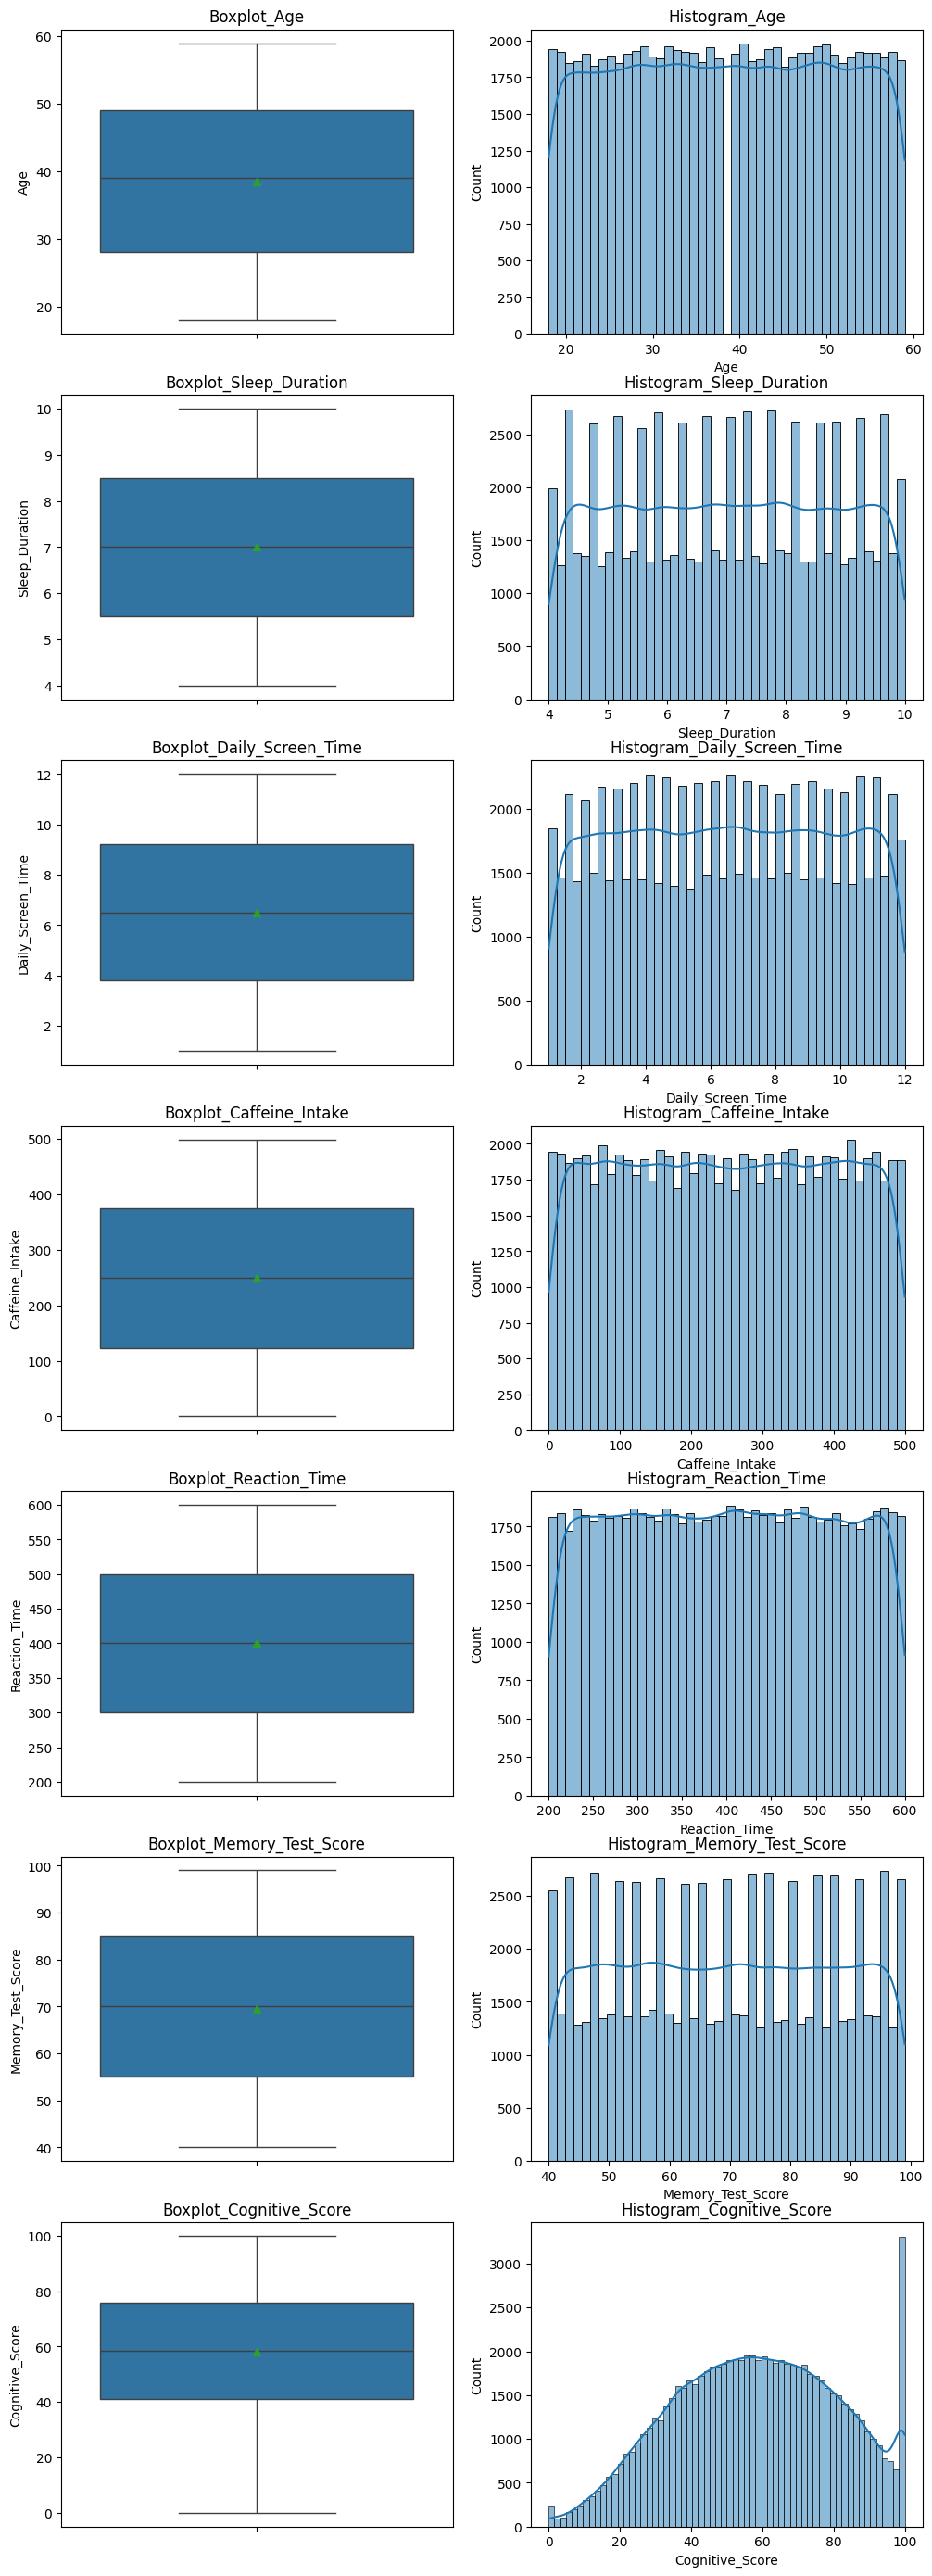

In [ ]:
num_feat = df.select_dtypes(include="number").drop(columns = ["Stress_Level", "AI_Predicted_Score"]) #escludiamo Stress_Level perchè è ordinale

n_cols = 2
n_rows = num_feat.shape[1]

fig, axes = plt.subplots(n_rows, n_cols, figsize = (12, 5*n_rows))

for row, var in enumerate(num_feat):
  sns.boxplot(data = df, y = var, ax = axes[row, 0], showmeans=True)
  axes[row, 0].set_title(f"Boxplot_{var}")

  sns.histplot(data = df, x = var, kde = True, ax = axes[row, 1])
  axes[row, 1].set_title(f"Histogram_{var}")

plt.show()

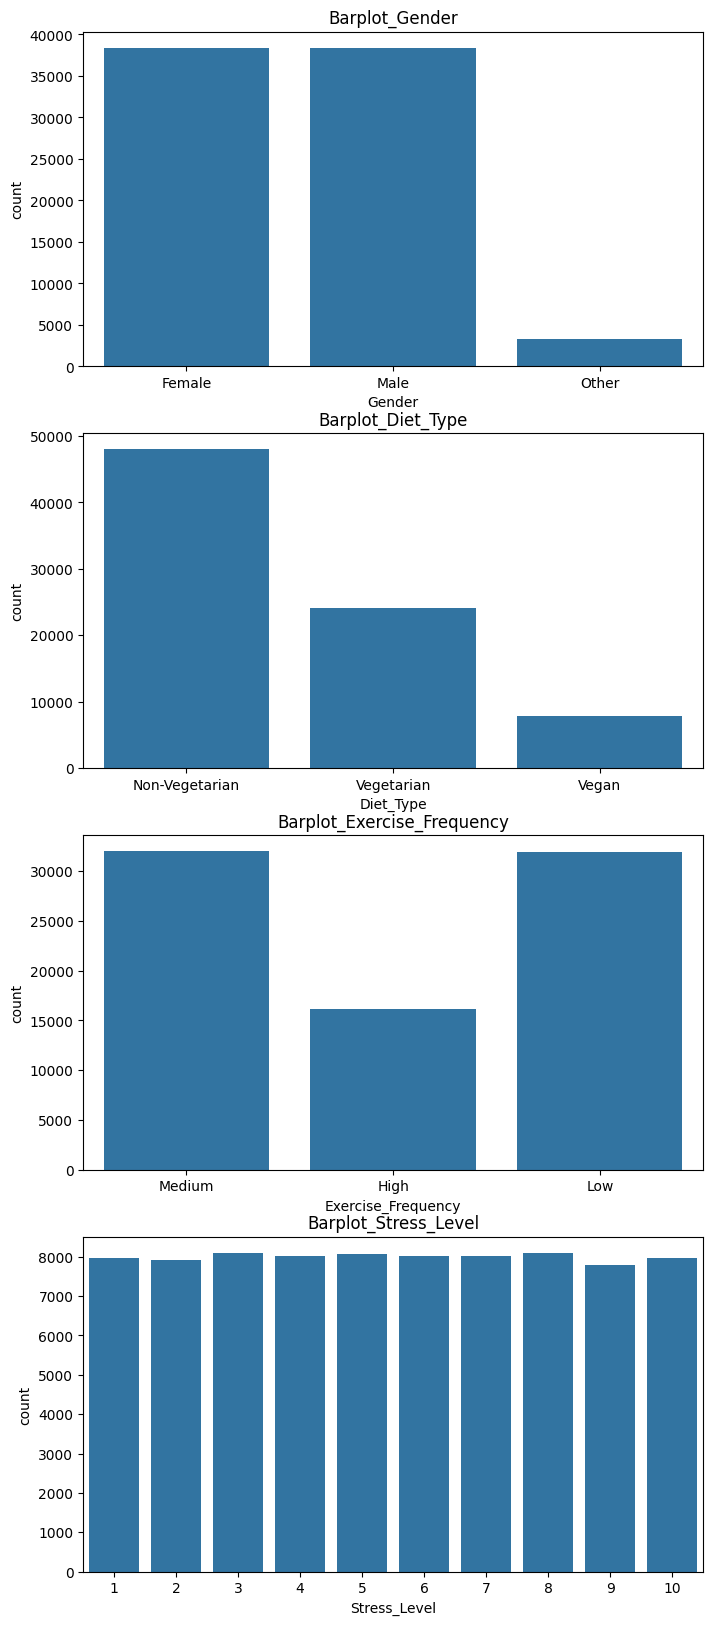

In [ ]:
#barplot
cat_feature = pd.concat([df.select_dtypes(include = "object").drop(columns = ["User_ID"]), df["Stress_Level"]], axis = 1)
n_rows = cat_feature.shape[1]

fig, axes = plt.subplots(n_rows, 1, figsize = (8, 5*n_rows))

for n_row, var in enumerate(cat_feature):
  sns.countplot(data = df, x = var, ax = axes[n_row])
  axes[n_row].set_title(f"Barplot_{var}")

plt.show()

In [ ]:
#controlliamo la percentuale delle classi meno rappresentate nelle features
print(df["Gender"].value_counts(normalize = True)) #Other è meno del 5%
print("---"*10)
print(df["Diet_Type"].value_counts(normalize = True)) #Vegan è corca il 10%
print("----"*10)
print(df["Exercise_Frequency"].value_counts(normalize = True)) #High è circa il 20%

Gender
Female    0.480050
Male      0.479025
Other     0.040925
Name: proportion, dtype: float64
------------------------------
Diet_Type
Non-Vegetarian    0.599825
Vegetarian        0.301700
Vegan             0.098475
Name: proportion, dtype: float64
----------------------------------------
Exercise_Frequency
Medium    0.399875
Low       0.398700
High      0.201425
Name: proportion, dtype: float64


In [ ]:
#check duplicates
any(df.duplicated()) #there aren't duplicated rows

False

No clear outlier values to be removed or duplicate rows were detected. For some features, an imbalance in class frequencies can be observed (Gender, DietType, and Exercise Frequency). In particular, in the Gender feature, the Other class accounts for less than 5% of the total observations in the column.

The target variable [Cognitive_Score] has a value range from 0 to 100. Since the method used to measure the target variable is unknown, we assume that Cognitive_Score values equal to zero are to be considered valid.

# Visualization Features vs Target

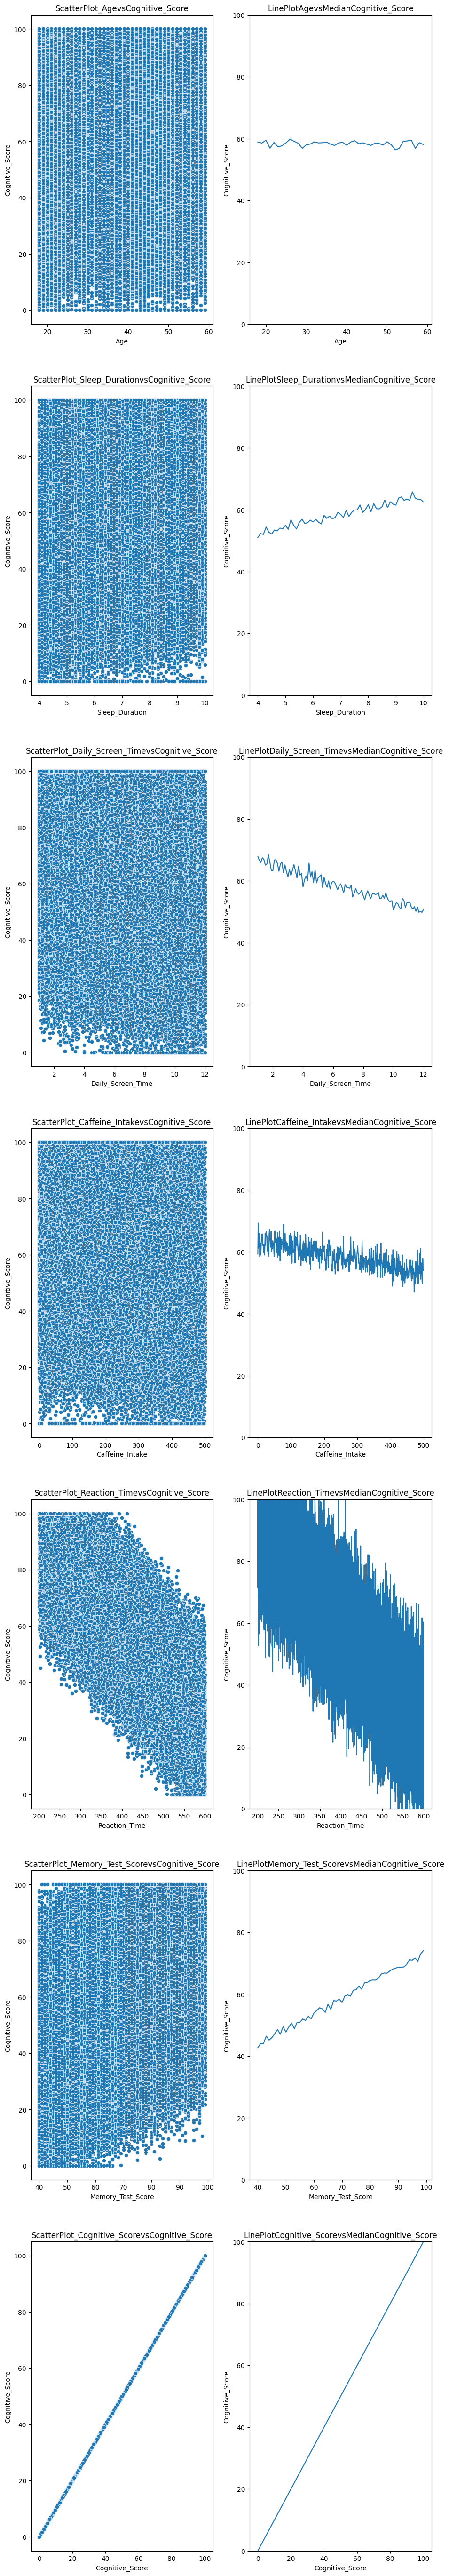

In [ ]:
rows = num_feat.shape[1]

fig, axes = plt.subplots(rows, 2, figsize = (11, 10*rows))

for n_row, var in enumerate(num_feat):
  sns.scatterplot(data = df, x = var, y = "Cognitive_Score", ax = axes[n_row, 0])
  axes[n_row, 0].set_title(f"ScatterPlot_{var}vsCognitive_Score")

  sns.lineplot(data = df, x = var, y = "Cognitive_Score", estimator = "median", errorbar=None, ax = axes[n_row, 1])
  axes[n_row, 1].set_ylim(0,100)
  axes[n_row, 1].set_title(f"LinePlot{var}vsMedianCognitive_Score")


plt.show()

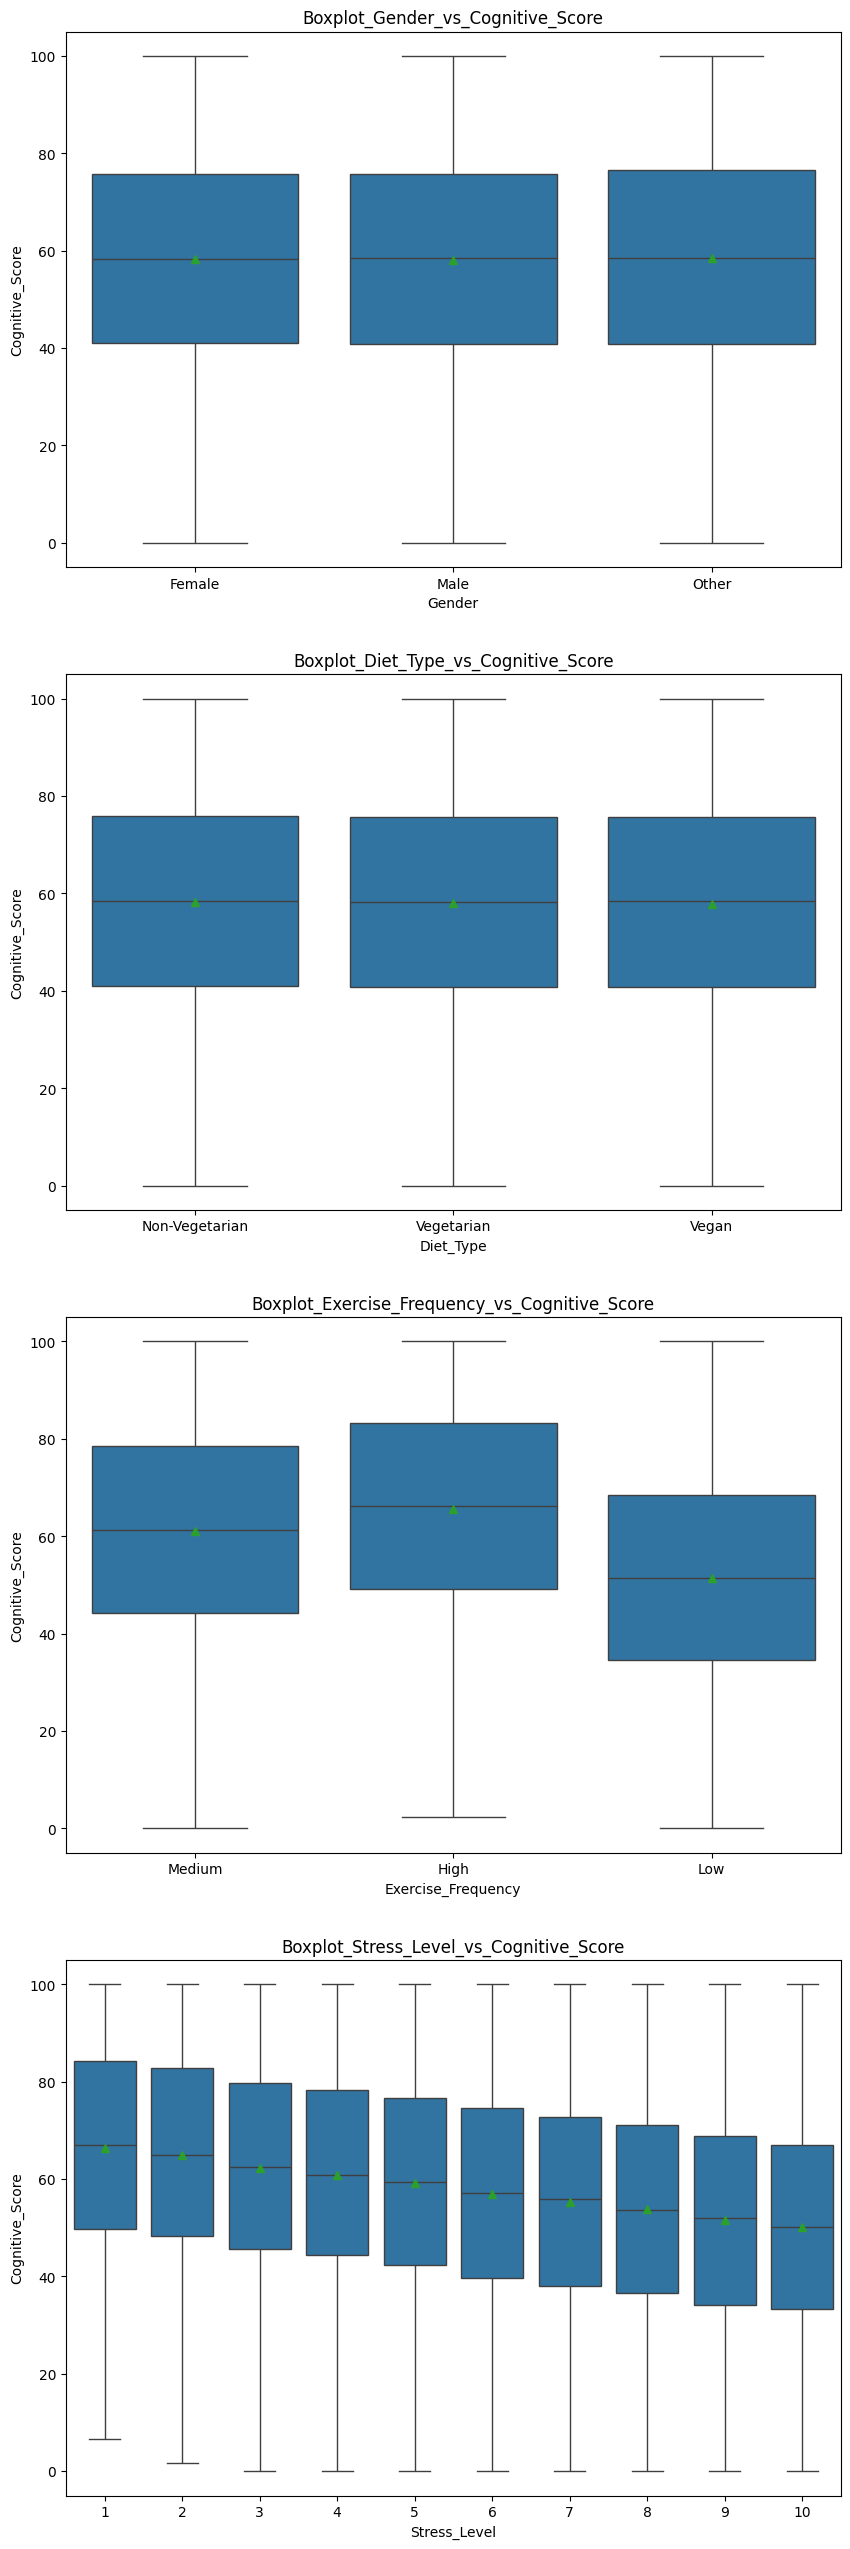

In [ ]:
rows = cat_feature.shape[1]

fig, axes = plt.subplots(rows, 1, figsize=(10, 8*rows))

for n_rows, var in enumerate(cat_feature):
  sns.boxplot(data = df, x = var , y = "Cognitive_Score", showmeans=True,  ax = axes[n_rows])
  axes[n_rows].set_title(f"Boxplot_{var}_vs_Cognitive_Score")

plt.show()

# Correlazione di features numeriche

<Axes: >

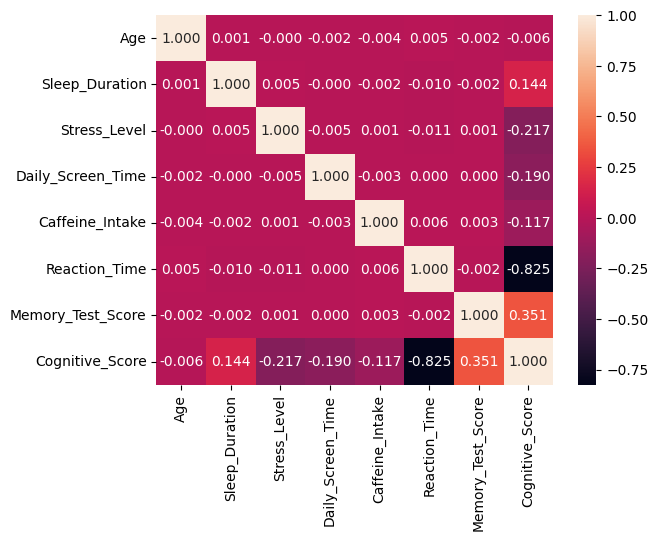

In [ ]:
sns.heatmap(df.select_dtypes(include = "number").drop(columns = "AI_Predicted_Score").corr(method = "spearman"), annot=True, fmt=".3f")

In [ ]:
#joint distributions categorical features
print(pd.crosstab(
    df["Gender"],
    df["Diet_Type"]
))

print("----"*15)

print(pd.crosstab(
    df["Gender"],
    df["Exercise_Frequency"]
))

print("----"*15)

print(pd.crosstab(
    df["Diet_Type"],
    df["Exercise_Frequency"]
))

Diet_Type  Non-Vegetarian  Vegan  Vegetarian
Gender                                      
Female              22983   3783       11638
Male                22991   3793       11538
Other                2012    302         960
------------------------------------------------------------
Exercise_Frequency  High    Low  Medium
Gender                                 
Female              7821  15361   15222
Male                7633  15223   15466
Other                660   1312    1302
------------------------------------------------------------
Exercise_Frequency  High    Low  Medium
Diet_Type                              
Non-Vegetarian      9649  19245   19092
Vegan               1623   3168    3087
Vegetarian          4842   9483    9811


In this second phase of the EDA, we observe that some features show a positive relationship with the target (Memory_Test_Score, Sleep_Duration, and Exercise_Frequency), while others exhibit a negative relationship (Reaction_Times, Screen_Time, and Stress_Level). Visually, Reaction_Times and Memory_Test_Score appear to have the strongest association with the target.
No evident issues of imperfect multicollinearity among numerical features or redundancy among categorical features are observed.

[We nevertheless choose Ridge regression to regularize the model and reduce the risk of unstable coefficients, especially considering the presence of categorical features with rare classes.]

# Features Selection

In [ ]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Sleep_Duration', 'Stress_Level',
       'Diet_Type', 'Daily_Screen_Time', 'Exercise_Frequency',
       'Caffeine_Intake', 'Reaction_Time', 'Memory_Test_Score',
       'Cognitive_Score', 'AI_Predicted_Score'],
      dtype='object')

In [ ]:
lst_feat = [col for col in df.columns if col not in ["User_ID","Cognitive_Score", "AI_Predicted_Score"]] #define list of variables we'll use for our models
X = df[lst_feat] #feauters
y = df["Cognitive_Score"] #target variable

In [ ]:
#divide feautures based on their type
num_features = [col for col in X.columns if col not in ["Gender", "Diet_Type", "Exercise_Frequency"]]
cat_features = ["Gender", "Diet_Type"]
ord_features = ["Exercise_Frequency"]

# Models fitting

In [ ]:
#different encoding methods depending on the algorithm used
encoding_ridge = ColumnTransformer(transformers=[("num", StandardScaler(), num_features),
                                           ("cat", OneHotEncoder(drop = None), cat_features), #drop=None beacause we won't interpret coefficients and Ridge has no problem with perfect multicollinearity
                                           ("ord", OrdinalEncoder(categories = [["Low", "Medium", "High"]]), ord_features)])
encoding_rf = ColumnTransformer(transformers=[("num", "passthrough", num_features),
                                           ("cat", OneHotEncoder(drop = None), cat_features),
                                           ("ord", OrdinalEncoder(categories = [["Low", "Medium", "High"]]), ord_features)])


In [ ]:
#define algorithms and parameter to test in the gridsearch
models = {"Ridge":{"encoding":encoding_ridge,
                 "model":Ridge(),
                 "params": {"model__alpha":[1e-3, 1e-2, 1e-1, 1, 10, 100]}},
        "RF":{"encoding":encoding_rf,
            "model":RandomForestRegressor(n_estimators = 300, random_state=42),
              "params":{"model__max_depth":[None, 5, 10],
                        "model__min_samples_leaf":[1,5]}}
        }

In [ ]:
rng = np.random.RandomState(42) #imposto un seed per reproducibilità


#define column names of our outcome dataframe
columns = ["R2", "MAE", "RMSE"]
columns.extend(list(X.columns))
columns.extend(["Model", "Run"])



rows = []
for model in models:

  pipe = Pipeline([("enc", models[model]["encoding"]),
                            ("model", models[model]["model"])]
                  )


  for i in range(3): #in the paper they did this loop x30
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=rng)

    grid = GridSearchCV(estimator=pipe,
                           param_grid=models[model]["params"],
                           cv=5, n_jobs=-1, verbose=1, scoring = 'neg_root_mean_squared_error') #sklearn maximasizes the negative RMSE

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_ #select the best model
    model_fitted = best_model.fit(X_train, y_train) #fit the best model to the training data
    y_pred = model_fitted.predict(X_test) #predictions of the best model

    report = {
      "R2": np.round(r2_score(y_test, y_pred), 3),
      "MAE": np.round(mean_absolute_error(y_test, y_pred),3),
      "RMSE": np.round(root_mean_squared_error(y_test, y_pred),3)
  }

    result_featimp = permutation_importance(model_fitted, X_test, y_test, scoring = "neg_root_mean_squared_error", n_repeats = 5, random_state = 42) #we implement a permutation
    #to determine features importance

    report.update(dict(zip(X_test.columns, result_featimp["importances_mean"])))
    report.update({"Model":model, "Run":i})

    rows.append(report)

df_out = pd.DataFrame(rows, columns = columns)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
df_out
df_out.to_csv("/content/drive/MyDrive/Test_ML/CognitivePerformance/df_results.csv", index = False)

# Evaluation of the Models

In [ ]:
#df_out = pd.read_csv("/content/drive/MyDrive/Test_ML/CognitivePerformance/df_results.csv")
df_out.groupby("Model")[["R2", "MAE", "RMSE"]].agg(["mean", "std"])

R2         MAE                RMSE          
        mean  std   mean       std      mean       std
Model                                                 
RF     0.988  0.0  1.990  0.017436  2.516667  0.023861
Ridge  0.993  0.0  1.308  0.007810  1.937667  0.005859

Above we reported the mean and standard deviation (computed over three repetitions within the train–test cycle) of the three metrics used to evaluate the models’ performance.

Across all the analyzed metrics, Ridge Regression consistently outperforms Random Forest Regression, achieving higher R² values and lower MAE and RMSE. Both models, however, show high predictive performance, with high R² and relatively small MAE and RMSE values, especially considering that the target variable ranges from 0 to 100.

Moreover, the small standard deviation across repetitions indicates good robustness and stability for both algorithms.

# Features Importance

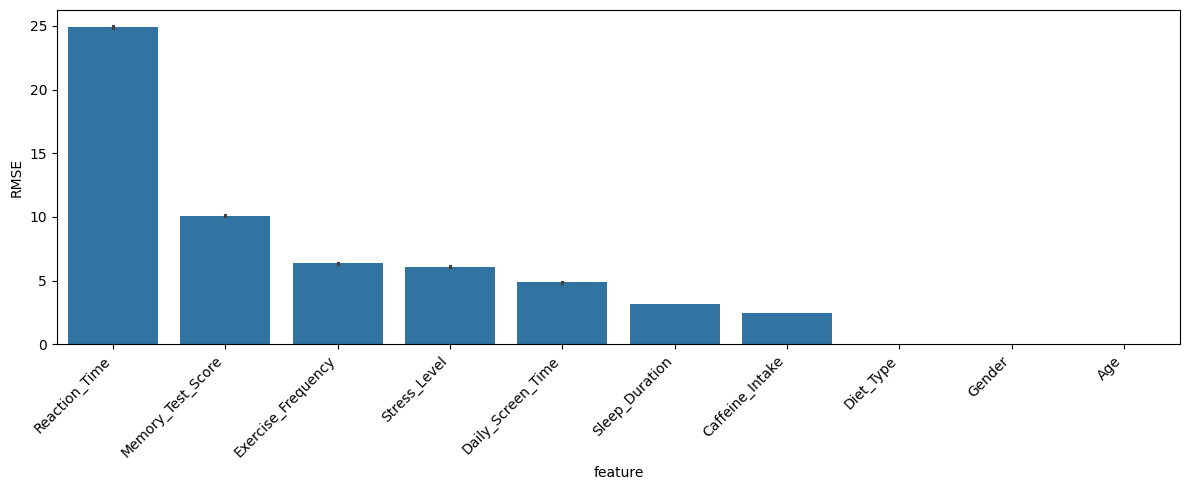

In [ ]:
fig = plt.figure(figsize=(12, 5))
feat_imp_plot = df_out.loc[df_out["Model"] == "Ridge", X.columns]
df_long_plot = feat_imp_plot.T.stack().reset_index().drop(columns = "level_1").rename(columns = {"level_0":"feature", 0:"RMSE"})
order = (
    df_long_plot.groupby("feature")["RMSE"]
      .mean()
      .sort_values(ascending=False)
      .index
)
sns.barplot(data = df_long_plot, x = "feature", y = "RMSE", estimator = "mean", errorbar="sd", order = order)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In line with the EDA, Reaction_Time emerges as the most informative feature for the Ridge Regression model. The plot shows the average permutation importance values, measured as the increase in RMSE caused by permuting each feature, while the error bars represent the standard deviation computed across the three iterations.